In [81]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px 
from datetime import datetime
mpl.rcParams['figure.figsize'] = (15, 7)
mpl.rcParams['axes.grid'] = False

from dateutil.parser import parse
dateparse=lambda dates:parse(dates)



import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler , StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import LSTM,Dense,Dropout,SimpleRNN,GRU,Bidirectional
from tensorflow.keras.models import Sequential

In [82]:
mpl.rcParams['figure.figsize'] = (20, 7)
mpl.rcParams['axes.grid'] = False

In [95]:
data = pd.read_csv("c:/Users/Amir/Desktop/MLP/Sunspots .csv" ,usecols=['Date','Monthly Mean Total Sunspot Number'],parse_dates=['Date'],date_parser=dateparse)
data

C:\Users\Amir\AppData\Local\Temp\ipykernel_8496\4109916399.py:1: FutureWarning:

The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.



,Date,Monthly Mean Total Sunspot Number
0,1749-01-31,96.7
1,1749-02-28,104.3
2,1749-03-31,116.7
3,1749-04-30,92.8
4,1749-05-31,141.7
...,...,...
3260,2020-09-30,0.6
3261,2020-10-31,14.4
3262,2020-11-30,34.0
3263,2020-12-31,21.8


In [84]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3265 entries, 0 to 3264
Data columns (total 2 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   Date                               3265 non-null   datetime64[ns]
 1   Monthly Mean Total Sunspot Number  3265 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 51.1 KB


In [85]:
data.describe()

,Date,Monthly Mean Total Sunspot Number
count,3265,3265.000000
mean,1885-01-29 02:35:41.255742976,81.778775
min,1749-01-31 00:00:00,0.000000
25%,1817-01-31 00:00:00,23.900000
50%,1885-01-31 00:00:00,67.200000
75%,1953-01-31 00:00:00,122.500000
max,2021-01-31 00:00:00,398.200000
std,NaN,67.889277


In [96]:
df = data.copy()

In [87]:
df["Month"] = df.Date.dt.month

df.head()

,Date,Monthly Mean Total Sunspot Number,Month
0,1749-01-31,96.7,1
1,1749-02-28,104.3,2
2,1749-03-31,116.7,3
3,1749-04-30,92.8,4
4,1749-05-31,141.7,5


In [88]:
df["nt_year"] = [int(str(i)[3]) for i in (df.Date.dt.year)]
df["nt_year"].replace(0 , 10 , inplace  =True)
df

C:\Users\Amir\AppData\Local\Temp\ipykernel_8496\2124362729.py:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





,Date,Monthly Mean Total Sunspot Number,Month,nt_year
0,1749-01-31,96.7,1,9
1,1749-02-28,104.3,2,9
2,1749-03-31,116.7,3,9
3,1749-04-30,92.8,4,9
4,1749-05-31,141.7,5,9
...,...,...,...,...
3260,2020-09-30,0.6,9,10
3261,2020-10-31,14.4,10,10
3262,2020-11-30,34.0,11,10
3263,2020-12-31,21.8,12,10


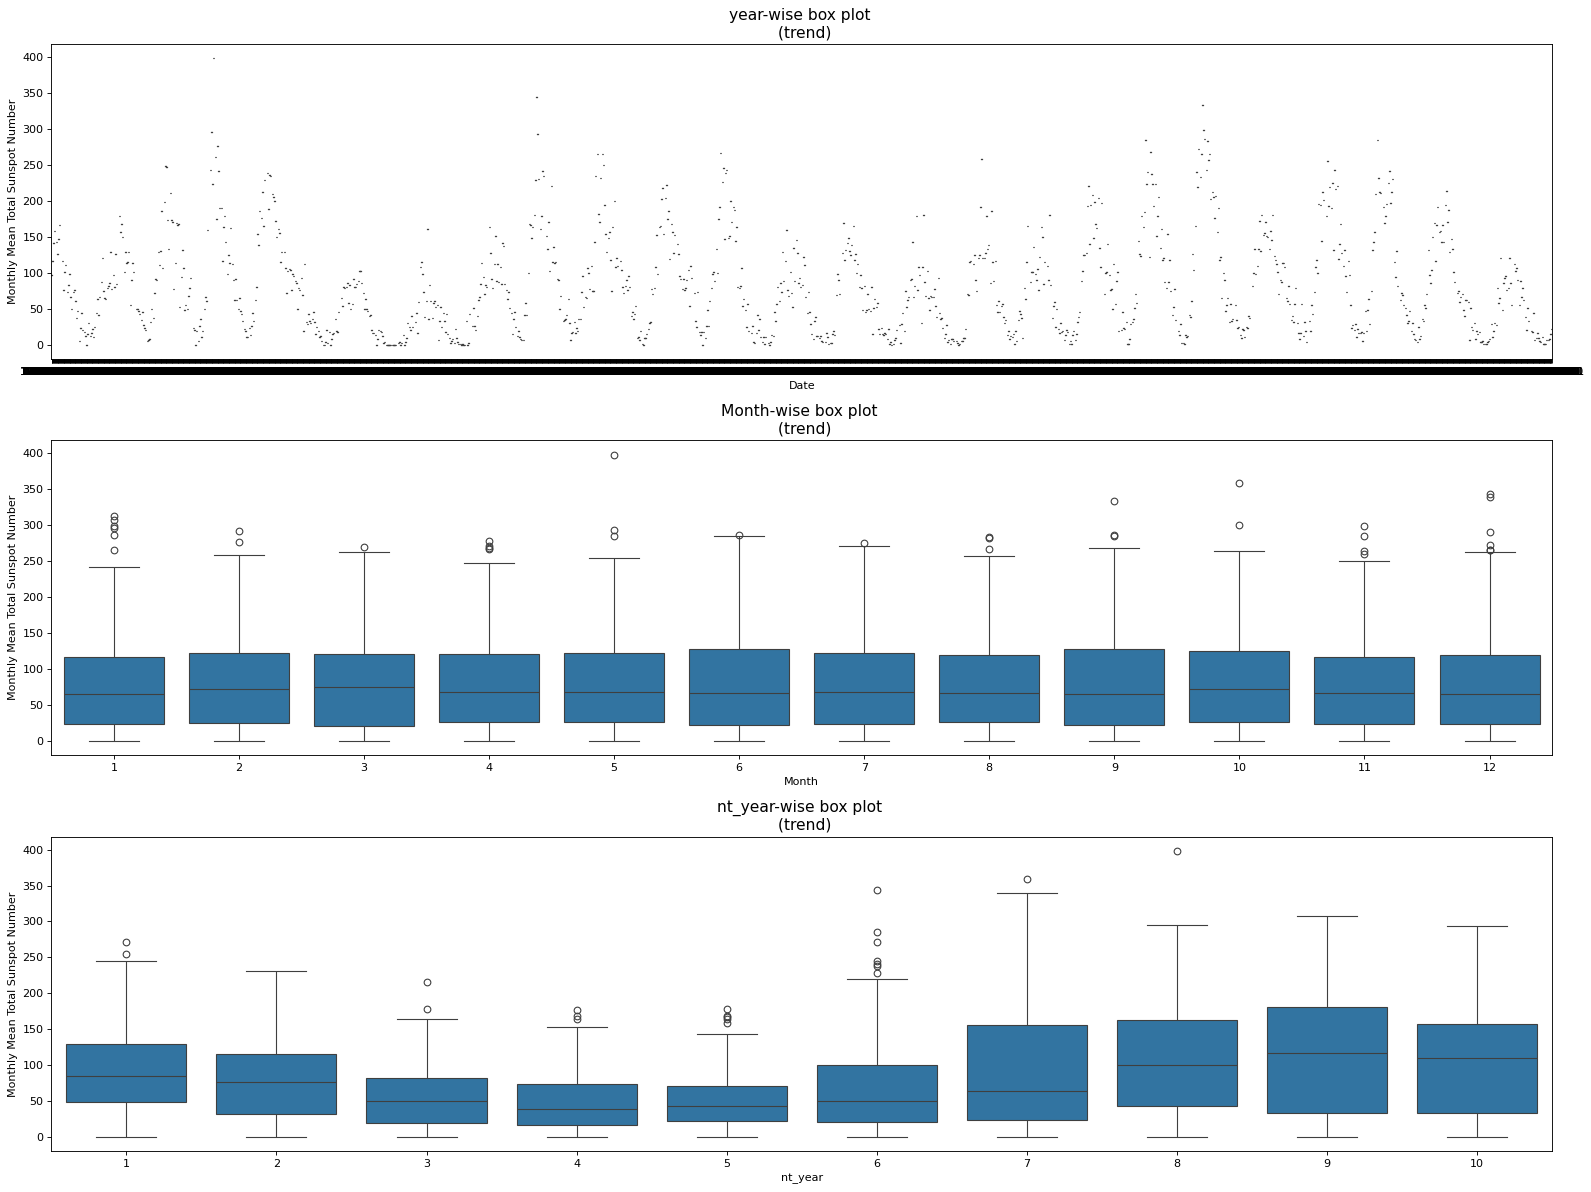

In [89]:
fig , axes = plt.subplots( 3 , 1 , figsize = ( 20 , 15) , dpi = 80)


sns.boxplot( x = "Date" , y = "Monthly Mean Total Sunspot Number" , data = df , ax = axes[0])
sns.boxplot(x = "Month" , y = "Monthly Mean Total Sunspot Number" , data = df , ax = axes[1])
sns.boxplot( x = "nt_year" , y = "Monthly Mean Total Sunspot Number" , data = df , ax = axes[2])


axes[0].set_title("year-wise box plot \n (trend)" , fontsize = 14)
axes[1].set_title("Month-wise box plot \n (trend)" , fontsize = 14)
axes[2].set_title("nt_year-wise box plot \n (trend)" , fontsize = 14)
fig.tight_layout()
plt.show()


In [90]:
data = data.set_index("Date")

data


,Monthly Mean Total Sunspot Number
Date,
1749-01-31,96.7
1749-02-28,104.3
1749-03-31,116.7
1749-04-30,92.8
1749-05-31,141.7
...,...
2020-09-30,0.6
2020-10-31,14.4
2020-11-30,34.0


In [91]:
df

,Date,Monthly Mean Total Sunspot Number,Month,nt_year
0,1749-01-31,96.7,1,9
1,1749-02-28,104.3,2,9
2,1749-03-31,116.7,3,9
3,1749-04-30,92.8,4,9
4,1749-05-31,141.7,5,9
...,...,...,...,...
3260,2020-09-30,0.6,9,10
3261,2020-10-31,14.4,10,10
3262,2020-11-30,34.0,11,10
3263,2020-12-31,21.8,12,10


<Axes: xlabel='Date'>

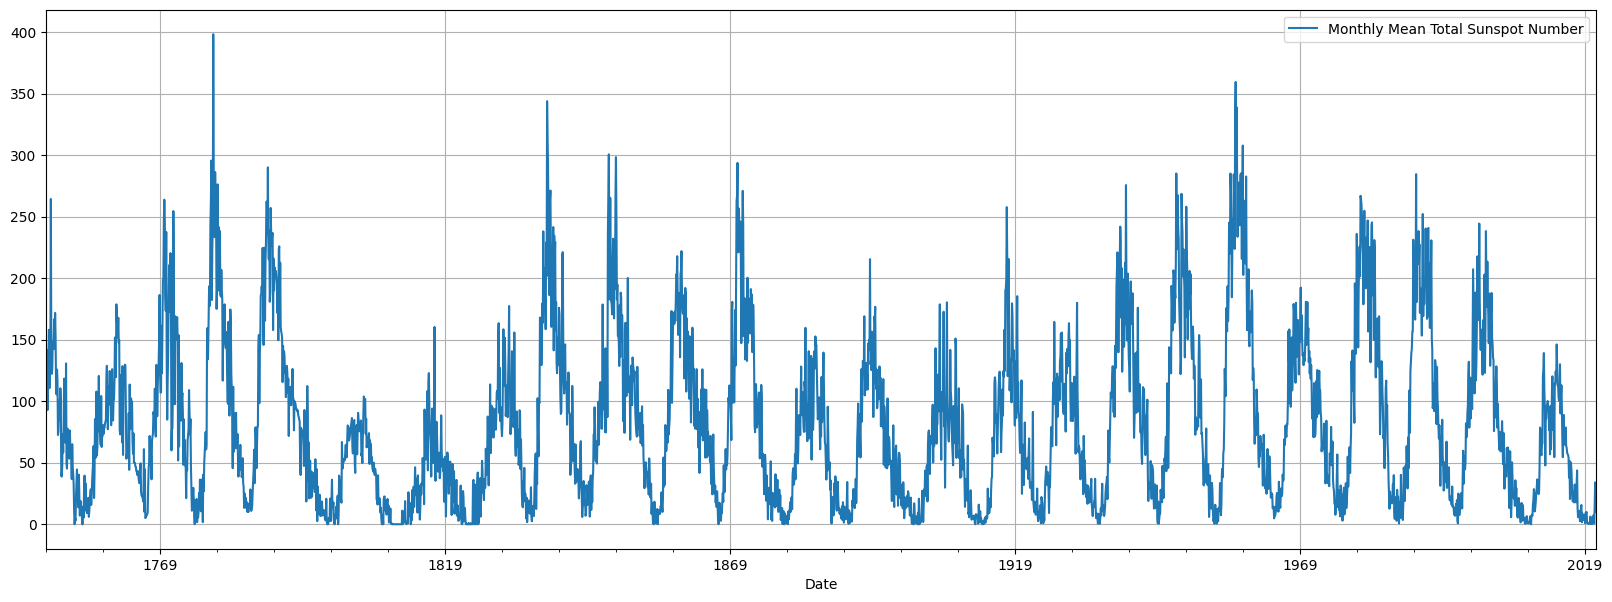

In [92]:
data.plot(grid = True)

In [93]:
data

,Monthly Mean Total Sunspot Number
Date,
1749-01-31,96.7
1749-02-28,104.3
1749-03-31,116.7
1749-04-30,92.8
1749-05-31,141.7
...,...
2020-09-30,0.6
2020-10-31,14.4
2020-11-30,34.0


In [97]:
fig = px.line(data , x ="Date" , y = "Monthly Mean Total Sunspot Number" , title = "Mean_Sunspot_Slide" )


fig.update_xaxes(
    rangeslider_visible = False,
    rangeselector = dict(
        buttons =list([
            dict(count = 10 , label = "10y" , step = "year" , stepmode = "backward"),
            dict(count = 20 , label = "20y" , step = "year" , stepmode = "backward"),
            dict(count = 30 , label = "30y" , step = "year" , stepmode = "backward"),
            dict(count = 40 , label = "40y" , step = "year" , stepmode = "backward"),
            dict(count = 50 , label = "50y" , step = "year" , stepmode = "backward"),
            dict(step = "all")
        ])
    )
)

fig.show()

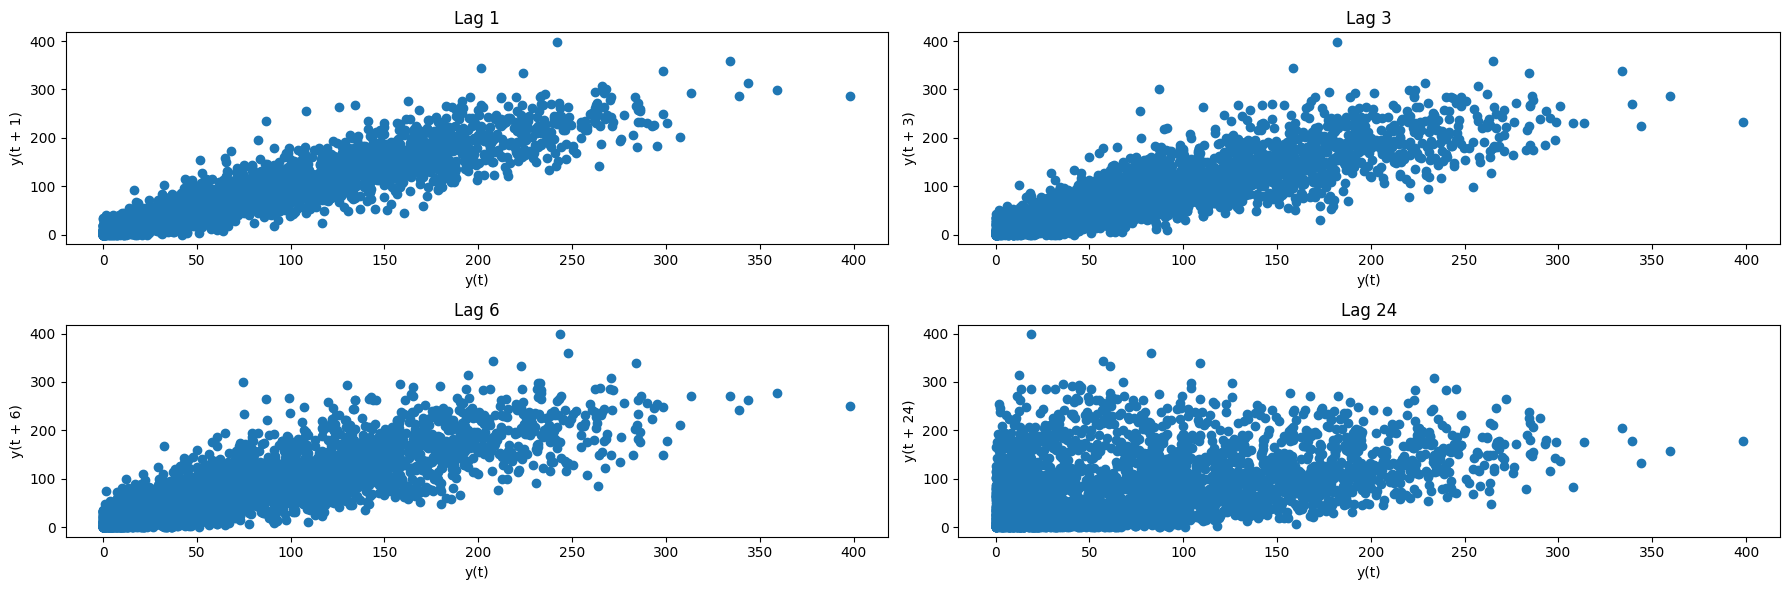

In [98]:
lags = [1, 3, 6, 24]

fig, axes = plt.subplots(2, 2, figsize=(18, 6))
axes = axes.flatten()

for ax, lag in zip(axes, lags):
    pd.plotting.lag_plot(
        df['Monthly Mean Total Sunspot Number'],
        lag=lag,
        ax=ax
    )
    ax.set_title(f'Lag {lag}')

plt.tight_layout()
plt.show()

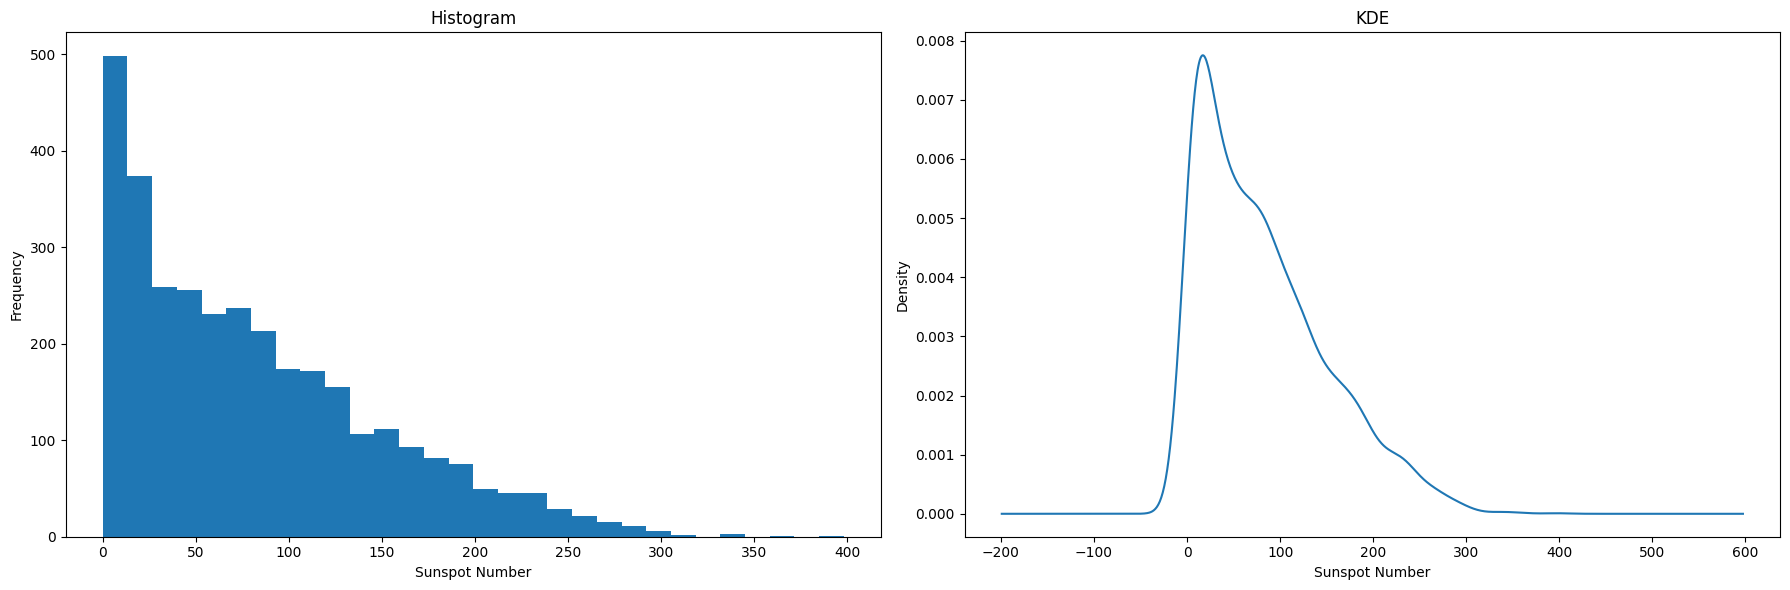

In [99]:
series = df['Monthly Mean Total Sunspot Number'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))


axes[0].hist(series, bins=30)
axes[0].set_title('Histogram')
axes[0].set_xlabel('Sunspot Number')
axes[0].set_ylabel('Frequency')


series.plot(kind='density', ax=axes[1])
axes[1].set_title('KDE')
axes[1].set_xlabel('Sunspot Number')

plt.tight_layout()
plt.show()


In [100]:
data

,Date,Monthly Mean Total Sunspot Number
0,1749-01-31,96.7
1,1749-02-28,104.3
2,1749-03-31,116.7
3,1749-04-30,92.8
4,1749-05-31,141.7
...,...,...
3260,2020-09-30,0.6
3261,2020-10-31,14.4
3262,2020-11-30,34.0
3263,2020-12-31,21.8


In [103]:
data_sun =data["Monthly Mean Total Sunspot Number"].values
data_sun

array([ 96.7, 104.3, 116.7, ...,  34. ,  21.8,  10.4], shape=(3265,))

In [109]:
len(data_sun)

3265

In [105]:
data_sun = data_sun.reshape(len(data_sun) , -1)
data_sun

array([[ 96.7],
       [104.3],
       [116.7],
       ...,
       [ 34. ],
       [ 21.8],
       [ 10.4]], shape=(3265, 1))

In [107]:
scaler = MinMaxScaler(feature_range=(0 , 1))

scaled_data = scaler.fit_transform(data_sun)
scaled_data = scaled_data.flatten()
scaled_data

array([0.24284279, 0.26192868, 0.29306881, ..., 0.08538423, 0.05474636,
       0.02611753], shape=(3265,))

In [110]:
x_train , x_test = train_test_split(scaled_data , test_size= 0.3 , random_state= 42 , shuffle= False)

x_train.shape , x_test.shape

((2285,), (980,))

In [117]:
time_step = 12

index = np.arange(time_step , len(x_train) , time_step)
index_2 = np.arange(time_step , len(x_test) , time_step)

x_train[12] , x_test[12]


(np.float64(0.3068809643395279), np.float64(0.35107985936715225))

In [118]:
y_train = x_train[index]
y_test = x_test[index_2]
y_train

array([0.30688096, 0.29306881, 0.14640884, 0.18407835, 0.        ,
       0.04269211, 0.05223506, 0.05901557, 0.15745856, 0.20215972,
       0.28176796, 0.29306881, 0.18332496, 0.23656454, 0.24987443,
       0.10045203, 0.05022602, 0.11476645, 0.22400804, 0.30939227,
       0.43520844, 0.15067805, 0.4224008 , 0.22852838, 0.19588147,
       0.0183325 , 0.09090909, 0.18834756, 0.7420894 , 0.48016072,
       0.29306881, 0.41310899, 0.22601708, 0.11727775, 0.05449523,
       0.02712205, 0.15570065, 0.56378704, 0.5775992 , 0.47714716,
       0.43119036, 0.30436966, 0.24284279, 0.23430437, 0.18834756,
       0.08965344, 0.09216474, 0.06027122, 0.00828729, 0.00678051,
       0.02887996, 0.11300854, 0.20015068, 0.20919136, 0.18960321,
       0.2553993 , 0.16323456, 0.05022602, 0.        , 0.03013561,
       0.        , 0.        , 0.04721246, 0.        , 0.09291813,
       0.08036163, 0.10999498, 0.15243596, 0.14590658, 0.13736816,
       0.08036163, 0.09040683, 0.        , 0.        , 0.09040

In [119]:
y_test

array([0.35107986, 0.25012557, 0.04746359, 0.03189352, 0.02059267,
       0.15118031, 0.30788548, 0.58287293, 0.59643395, 0.43294827,
       0.29708689, 0.35760924, 0.13058764, 0.07910598, 0.00100452,
       0.1135108 , 0.41461577, 0.71396283, 0.60999498, 0.59994977,
       0.39176293, 0.27498744, 0.14967353, 0.1285786 , 0.03390256,
       0.05851331, 0.17001507, 0.2395781 , 0.39226519, 0.37694626,
       0.37995982, 0.17754897, 0.31315922, 0.14088398, 0.12933199,
       0.04193872, 0.04495229, 0.13787042, 0.33802109, 0.53164239,
       0.5592667 , 0.33048719, 0.41109995, 0.33023606, 0.16348569,
       0.07106981, 0.00150678, 0.04721246, 0.3121547 , 0.71446509,
       0.38498242, 0.5642893 , 0.24736313, 0.17478654, 0.09969864,
       0.05650427, 0.04143646, 0.05223506, 0.22727273, 0.52034154,
       0.47212456, 0.50954294, 0.32345555, 0.29809141, 0.16700151,
       0.14264189, 0.06152687, 0.05349071, 0.01305876, 0.0158212 ,
       0.04721246, 0.14088398, 0.23103968, 0.19261678, 0.25841

In [123]:
x_train = x_train[range(len(y_train)*time_step)]
x_train.shape

(2280,)

In [127]:
x_train = np.reshape(x_train , (-1 , time_step,1))
x_train.shape

(190, 12, 1)

In [128]:
190*12

2280

In [135]:
model = Sequential()

model.add(SimpleRNN(units=8 , activation= "tanh" , return_sequences= False , input_shape = ((time_step , 1))))
model.add(Dense(1 , activation= "sigmoid"))
model.compile(optimizer = "adam" , loss = "mse")
model.fit(x_train , y_train , epochs = 20 , batch_size = 1)

Epoch 1/20


c:\Users\Amir\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



190/190 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0525
Epoch 2/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0169
Epoch 3/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0133
Epoch 4/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0116
Epoch 5/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0107
Epoch 6/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0107
Epoch 7/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0103
Epoch 8/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0098
Epoch 9/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0096
Epoch 10/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0090
Epoch 11/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0085
Epoch 12/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0084
Epoch 13/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0084
Epoch 14/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0085
Epoch 15/20
190/190 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0082


In [136]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 8)              │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 269 (1.05 KB)

 Trainable params: 89 (356.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 180 (724.00 B)

In [137]:
y_pred =  model.predict(x_train)


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


In [138]:
y_pred

array([[0.35940987],
       [0.40702823],
       [0.2018307 ],
       [0.16795321],
       [0.13852167],
       [0.09713663],
       [0.08178832],
       [0.08427201],
       [0.1531466 ],
       [0.19422118],
       [0.27549866],
       [0.2884553 ],
       [0.42363954],
       [0.28408304],
       [0.19646245],
       [0.14565215],
       [0.10669348],
       [0.07216869],
       [0.15852313],
       [0.31139863],
       [0.5307283 ],
       [0.48647204],
       [0.3588958 ],
       [0.3171972 ],
       [0.1251262 ],
       [0.1021504 ],
       [0.07967146],
       [0.10374534],
       [0.463306  ],
       [0.58181286],
       [0.50951946],
       [0.39243138],
       [0.30884835],
       [0.16286568],
       [0.10444819],
       [0.08275305],
       [0.13308907],
       [0.41012526],
       [0.5498711 ],
       [0.54956114],
       [0.49403247],
       [0.40807623],
       [0.27816302],
       [0.2635199 ],
       [0.17300962],
       [0.15045229],
       [0.10123874],
       [0.086

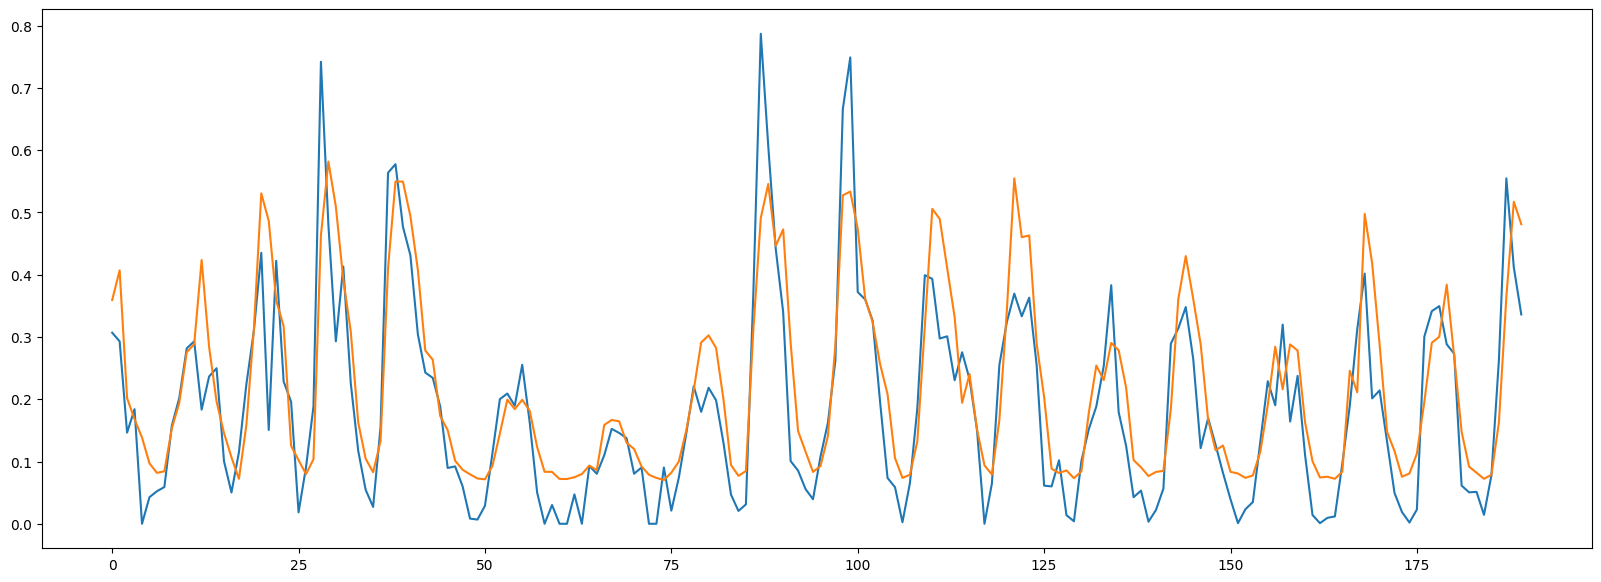

In [139]:
plt.plot(range(len(y_train)),y_train)
plt.plot(range(len(y_pred)),y_pred)
plt.show()

In [141]:
x_test = x_test[:len(x_test) - (len(x_test) % time_step)]
x_test = np.reshape(x_test , (-1 , time_step , 1))
y_pred_1 = model.predict(x_test)

y_pred_1

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


array([[0.3217517 ],
       [0.2498809 ],
       [0.20598237],
       [0.1088367 ],
       [0.07782158],
       [0.09960212],
       [0.24592468],
       [0.47550398],
       [0.4762136 ],
       [0.52380574],
       [0.445479  ],
       [0.23787849],
       [0.17122136],
       [0.09940396],
       [0.07260321],
       [0.0876287 ],
       [0.34737304],
       [0.5513932 ],
       [0.5872363 ],
       [0.5716034 ],
       [0.5040561 ],
       [0.28759986],
       [0.17518458],
       [0.10537123],
       [0.09387494],
       [0.08601023],
       [0.10620576],
       [0.3373064 ],
       [0.40301147],
       [0.43931827],
       [0.43040773],
       [0.34632897],
       [0.26349062],
       [0.19205593],
       [0.11308522],
       [0.09436822],
       [0.08198588],
       [0.08806947],
       [0.22295837],
       [0.49508068],
       [0.547199  ],
       [0.5128373 ],
       [0.49589276],
       [0.33403403],
       [0.23505306],
       [0.09041777],
       [0.08150787],
       [0.078

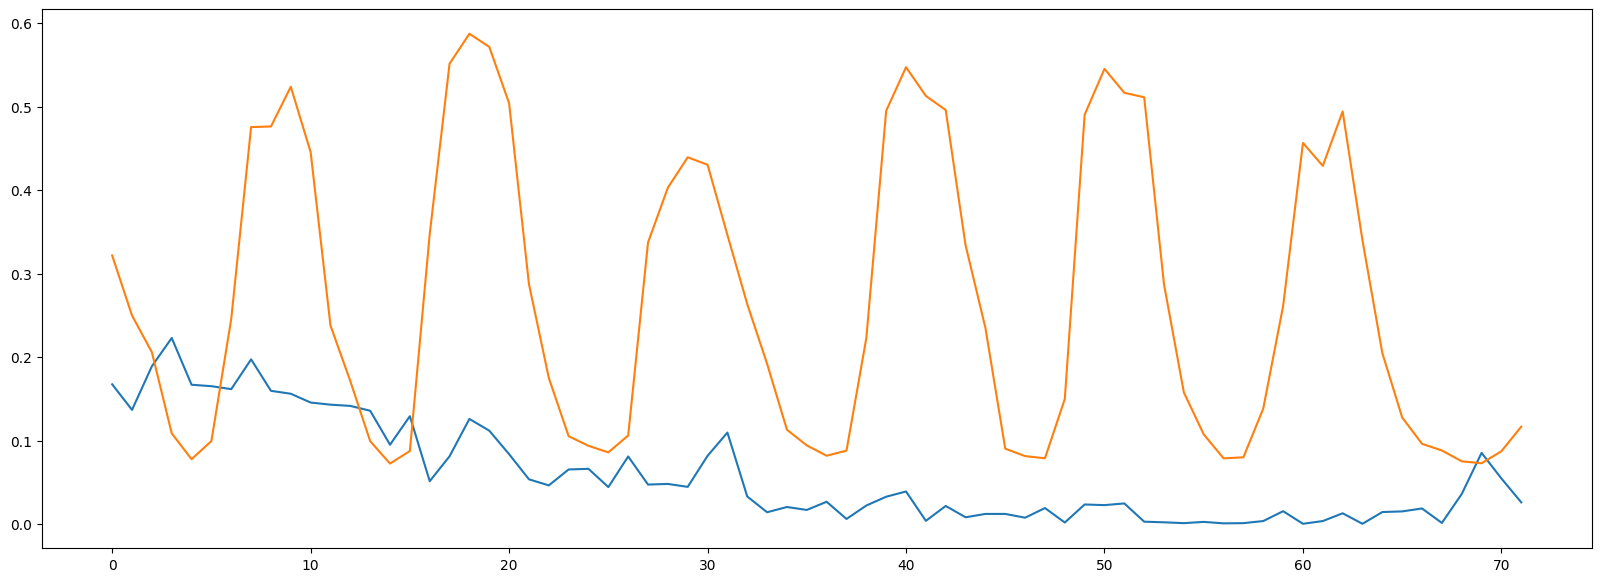

In [146]:
orginal_test_data = scaled_data[len(x_train):]

start_y_train  = len(orginal_test_data) - len(y_pred_1)

y_test = orginal_test_data[start_y_train:]

y_pred_1 = y_pred_1.flatten()

plt.plot(range(len(y_test)),y_test)
plt.plot(range(len(y_pred_1)),y_pred_1)
plt.show()